Copyright (c) MONAI Consortium  
Licensed under the Apache License, Version 2.0 (the "License");  
you may not use this file except in compliance with the License.  
You may obtain a copy of the License at  
&nbsp;&nbsp;&nbsp;&nbsp;http://www.apache.org/licenses/LICENSE-2.0  
Unless required by applicable law or agreed to in writing, software  
distributed under the License is distributed on an "AS IS" BASIS,  
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.  
See the License for the specific language governing permissions and  
limitations under the License.

# MAISI VAE Training Tutorial

This tutorial illustrates how to train the VAE model in MAISI on CT and MRI datasets. The VAE model is used for latent feature compression, which significantly reduce the memory usage of the diffusion model. The released VAE model weights can work on both CT and MRI images.

In [1]:
from google.colab import drive

# 挂载 Google Drive 到 /content/drive
drive.mount('/content/drive')
print("Google Drive 挂载成功！")
print("模型将保存在 /content/drive/MyDrive/MAISI_VAE_Training 目录下。")

Mounted at /content/drive
Google Drive 挂载成功！
模型将保存在 /content/drive/MyDrive/MAISI_VAE_Training 目录下。


In [2]:
import os
from google.colab import userdata

# 1. 从 Colab 安全存储中读取 Key
try:
    wandb_key = userdata.get('WANDB_API_KEY')

    # 2. 将其设置为环境变量（W&B 会自动识别这个变量名）
    os.environ["WANDB_API_KEY"] = wandb_key

    import wandb
    # 3. 登录。因为有了环境变量，这一步会直接成功，不会跳出交互窗口
    wandb.login()
    print("W&B 自动登录成功！🚀")
except Exception as e:
    print(f"自动登录失败，请检查 Secrets 是否配置正确。错误: {e}")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: d6f5g4123 (d6f5g4123-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B 自动登录成功！🚀


In [3]:
import os

# 克隆 GitHub 仓库
!git clone https://github.com/d6f5g4123-arch/NV-Generate-CTMR.git /content/github_data

# 切换工作目录到仓库目录，以便后续能够直接读取库中的脚本和数据
os.chdir('/content/github_data')
print("GitHub 仓库已克隆，工作目录已切换至 /content/github_data。")

Cloning into '/content/github_data'...
remote: Enumerating objects: 456, done.
remote: Counting objects: 100% (246/246), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 456 (delta 206), reused 173 (delta 173), pack-reused 210 (from 3)
Receiving objects: 100% (456/456), 40.72 MiB | 16.39 MiB/s, done.
Resolving deltas: 100% (259/259), done.
GitHub 仓库已克隆，工作目录已切换至 /content/github_data。


## Setup environment

In [4]:
!python -c "import monai" || pip install -q "monai-weekly[nibabel, tqdm]"
!python -c "import matplotlib" || pip install -q matplotlib
!python -c "import tensorboard" || python -m pip install -U tensorboard
!python -c "import lpips" || python -m pip install -U lpips
%matplotlib inline

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 91.7 MB/s eta 0:00:00
Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'lpips'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 6.7 MB/s eta 0:00:00


## Setup imports

In [5]:
import argparse
import glob
import json
import os
import tempfile
from pathlib import Path

import torch
from monai.networks.nets import PatchDiscriminator
from monai.apps import download_and_extract
from monai.config import print_config
from monai.data import CacheDataset, DataLoader
from monai.inferers.inferer import SimpleInferer, SlidingWindowInferer
from monai.losses.adversarial_loss import PatchAdversarialLoss
from monai.losses.perceptual import PerceptualLoss
from monai.utils import set_determinism
from torch.amp import GradScaler, autocast
from torch.nn import L1Loss, MSELoss
from torch.optim import lr_scheduler
from torch.utils.tensorboard import SummaryWriter

from scripts.transforms import VAE_Transform
from scripts.utils import KL_loss, define_instance, dynamic_infer
from scripts.utils_plot import find_label_center_loc, get_xyz_plot, show_image
from scripts.download_model_data import download_model_data

import warnings

warnings.filterwarnings("ignore")

print_config()

MONAI version: 1.6.dev2612
Numpy version: 2.0.2
Pytorch version: 2.10.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 42d23a410d875c107bc893df5d77a5a2797dc2ef
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.4.2
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.1
TorchVision version: 0.25.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.2
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://monai.readthe

## Setup data directory
You can specify a directory with the `MONAI_DATA_DIRECTORY` environment variable.
This allows you to save results and reuse downloads.
If not specified a temporary directory will be used.

In [6]:
os.environ["MONAI_DATA_DIRECTORY"] = "./temp_work_dir"
directory = os.environ.get("MONAI_DATA_DIRECTORY")
if directory is not None:
    os.makedirs(directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if directory is None else directory

generate_version = "rflow-ct"


## Download dataset

This tutorial shows how to train a VAE with both CT and MRI data. We use MSD 09 Spleen segmentation and MSD 01 Brats16&17 Brain Tumor segmentation as examples. The dataset comes from http://medicaldecathlon.com/.

This is just an example on how to build a multi-modal training dataset with both CT and MRI involved. Users can choose their own training datasets.

For the released trained autoencoder model weights, we used CT and MRI data from [TCIA Covid 19 Chest CT](https://wiki.cancerimagingarchive.net/display/Public/CT+Images+in+COVID-19#70227107b92475d33ae7421a9b9c426f5bb7d5b3), [TCIA Colon Abdomen CT](https://wiki.cancerimagingarchive.net/pages/viewpage.action?pageId=3539213), [MSD03 Liver Abdomen CT](http://medicaldecathlon.com/), [LIDC chest CT](https://www.cancerimagingarchive.net/collection/lidc-idri/), [TCIA Stony Brook Covid Chest CT](https://www.cancerimagingarchive.net/collection/covid-19-ny-sbu/), [NLST Chest CT](https://www.cancerimagingarchive.net/collection/nlst/), [TCIA Upenn GBM Brain MR](https://wiki.cancerimagingarchive.net/pages/viewpage.action?pageId=70225642), [Aomic Brain MR](https://openneuro.org/datasets/ds003097/versions/1.2.1), [QTIM Brain MR](https://openneuro.org/datasets/ds004169/versions/1.0.7), [TCIA Acrin Chest MR](https://www.cancerimagingarchive.net/collection/acrin-contralateral-breast-mr/), [TCIA Prostate MR Below-Abdomen MR](https://wiki.cancerimagingarchive.net/pages/viewpage.action?pageId=68550661#68550661a2c52df5969d435eae49b9669bea21a6). In total, we have
- number of CT training data: 37243
- number of MRI training data: 17887
- number of CT validation data:1963
- number of MRI validation data: 940

In [7]:
demo_train_data_rootdir = os.path.join(root_dir, "demo_train_datasets")
drive_dataset_root = "/content/drive/MyDrive/MAISI_VAE_Training/datasets"

# --- Check and Load MSD Spleen CT data ---
resource = "https://msd-for-monai.s3-us-west-2.amazonaws.com/Task09_Spleen.tar"
md5 = "410d4a301da4e5b2f6f86ec3ddba524e"

drive_path_1 = os.path.join(drive_dataset_root, "Task09_Spleen")
if os.path.exists(drive_path_1):
    data_path_1 = drive_path_1
    print(f"检测到 Drive 中的 Spleen 数据集，直接调用: {data_path_1}")
else:
    compressed_file = os.path.join(demo_train_data_rootdir, "Task09_Spleen.tar")
    data_path_1 = os.path.join(demo_train_data_rootdir, "Task09_Spleen")
    if not os.path.exists(data_path_1):
        download_and_extract(resource, compressed_file, demo_train_data_rootdir, md5)

train_images_1 = sorted(glob.glob(os.path.join(data_path_1, "imagesTr", "*.nii.gz")))
data_dicts_1 = [{"image": image_name} for image_name in train_images_1]
len_train = int(0.8 * len(data_dicts_1))
train_files_1, val_files_1 = data_dicts_1[:len_train], data_dicts_1[len_train:]

# --- Check and Load MSD Brats MRI data ---
resource = "https://msd-for-monai.s3-us-west-2.amazonaws.com/Task01_BrainTumour.tar"
md5 = "240a19d752f0d9e9101544901065d872"

drive_path_2 = os.path.join(drive_dataset_root, "Task01_BrainTumour")
if os.path.exists(drive_path_2):
    data_path_2 = drive_path_2
    print(f"检测到 Drive 中的 Brats 数据集，直接调用: {data_path_2}")
else:
    compressed_file = os.path.join(demo_train_data_rootdir, "Task01_BrainTumour.tar")
    data_path_2 = os.path.join(demo_train_data_rootdir, "Task01_BrainTumour")
    if not os.path.exists(data_path_2):
        download_and_extract(resource, compressed_file, demo_train_data_rootdir, md5)

train_images_2 = sorted(glob.glob(os.path.join(data_path_2, "imagesTr", "*.nii.gz")))
data_dicts_2 = [{"image": image_name} for image_name in train_images_2]
len_train = int(0.8 * len(data_dicts_2))
train_files_2, val_files_2 = data_dicts_2[:len_train], data_dicts_2[len_train:]

datasets = {
    1: {
        "data_name": "Dataset 1 MSD09 Spleen Abdomen CT",
        "train_files": train_files_1,
        "val_files": val_files_1,
        "modality": "ct",
    },
    2: {
        "data_name": "Dataset 2 MSD01 Brats Brain MRI",
        "train_files": train_files_2,
        "val_files": val_files_2,
        "modality": "mri",
    },
}

检测到 Drive 中的 Spleen 数据集，直接调用: /content/drive/MyDrive/MAISI_VAE_Training/datasets/Task09_Spleen
检测到 Drive 中的 Brats 数据集，直接调用: /content/drive/MyDrive/MAISI_VAE_Training/datasets/Task01_BrainTumour


## Read in environment setting, including data directory, model directory, and output directory

The information for data directory, model directory, and output directory are saved in `"./configs/environment_maisi_vae_train.json"`

In [8]:
args = argparse.Namespace()

environment_file = "./configs/environment_maisi_vae_train.json"
env_dict = json.load(open(environment_file, "r"))
for k, v in env_dict.items():
    setattr(args, k, v)
    print(f"{k}: {v}")

# --- Overwrite model_dir to Google Drive ---
args.model_dir = "/content/drive/MyDrive/MAISI_VAE_Training"
print(f"\nModel directory manually updated to Google Drive: {args.model_dir}")

# model path
Path(args.model_dir).mkdir(parents=True, exist_ok=True)
trained_g_path = os.path.join(args.model_dir, "autoencoder.pt")
trained_d_path = os.path.join(args.model_dir, "discriminator.pt")
print(f"Trained model will be saved as {trained_g_path} and {trained_d_path}.")

# 如果 Drive 里已有训练过的模型，直接跳过下载
if os.path.exists(trained_g_path):
    print(f"✅ 检测到 Drive 中已有训练模型，跳过下载")
else:
    print(f"⬇️ 未检测到训练模型，从 HuggingFace 下载预训练权重...")
    download_model_data(generate_version, root_dir, model_only=True)

# initialize tensorboard writer
Path(args.tfevent_path).mkdir(parents=True, exist_ok=True)
tensorboard_path = os.path.join(args.tfevent_path, "autoencoder")
Path(tensorboard_path).mkdir(parents=True, exist_ok=True)
tensorboard_writer = SummaryWriter(tensorboard_path)
print(f"Tensorboard event will be saved as {tensorboard_path}.")
print(f"Whether load pretrained model and finetune on it: {args.finetune}")

model_dir: ./models/
tfevent_path: ./outputs/tfevent
trained_autoencoder_path: models/autoencoder_v1.pt
finetune: True

Model directory manually updated to Google Drive: /content/drive/MyDrive/MAISI_VAE_Training
Trained model will be saved as /content/drive/MyDrive/MAISI_VAE_Training/autoencoder.pt and /content/drive/MyDrive/MAISI_VAE_Training/discriminator.pt.
✅ 检测到 Drive 中已有训练模型，跳过下载
Tensorboard event will be saved as ./outputs/tfevent/autoencoder.
Whether load pretrained model and finetune on it: True


## Read in configuration setting, including network definition, body region and anatomy to generate, etc.

The information for the training hyperparameters and data processing parameters, like learning rate and patch size, are stored in `"./configs/config_maisi_vae_train"`. Please refer to README.md for the details.

In [9]:
config_file = "./configs/config_network_rflow.json"
config_dict = json.load(open(config_file, "r"))
for k, v in config_dict.items():
    setattr(args, k, v)


# check the format of inference inputs
config_train_file = "./configs/config_maisi_vae_train.json"
config_train_dict = json.load(open(config_train_file, "r"))
for k, v in config_train_dict["data_option"].items():
    setattr(args, k, v)
    print(f"{k}: {v}")
for k, v in config_train_dict["autoencoder_train"].items():
    setattr(args, k, v)
    print(f"{k}: {v}")

print("Network definition and training hyperparameters have been loaded.")
# --- 动态调整以适配 L4 显存 ---
args.batch_size = 4           # 3D 任务建议先从 1 开始跑通
args.patch_size = [96, 96, 96] # 降回 64^3，显存压力会减小 8 倍
args.n_epochs = 100            # 增加轮数，一个 epoch 根本没效果
args.val_interval = 5          # 每个 epoch 验证一次，方便 W&B 看图
args.cache = 1.0               # 利用 53GB 内存全量缓存
args.perceptual_weight = 0.1   # 如果还炸，就把这个设为 0
args.kl_weight = 1e-06
args.adv_weight = args.adv_weight * 0.5
args.val_sliding_window_patch_size = [96, 96, 96]

print(f"参数已重置: Batch={args.batch_size}, Patch={args.patch_size}")

random_aug: True
spacing_type: rand_zoom
spacing: None
select_channel: 0
batch_size: 8
patch_size: [128, 128, 128]
val_batch_size: 1
val_patch_size: None
val_sliding_window_patch_size: [96, 96, 64]
lr: 0.0001
perceptual_weight: 0.3
kl_weight: 1e-07
adv_weight: 0.1
recon_loss: l1
val_interval: 1
cache: 1.0
amp: True
n_epochs: 100
Network definition and training hyperparameters have been loaded.
参数已重置: Batch=4, Patch=[96, 96, 96]


## Set deterministic training for reproducibility

In [10]:
set_determinism(seed=0)

## Build training dataset

In [11]:
# Initialize file lists
train_files = {"ct": [], "mri": []}
val_files = {"ct": [], "mri": []}


# Function to add assigned class to datalist
def add_assigned_class_to_datalist(datalist, classname):
    for item in datalist:
        item["class"] = classname
    return datalist


# Process datasets
for _, dataset in datasets.items():
    train_files_i = dataset["train_files"]
    val_files_i = dataset["val_files"]
    print(f"{dataset['data_name']}: number of training data is {len(train_files_i)}.")
    print(f"{dataset['data_name']}: number of val data is {len(val_files_i)}.")

    # attach modality to each file
    modality = dataset["modality"]
    train_files[modality] += add_assigned_class_to_datalist(train_files_i, modality)
    val_files[modality] += add_assigned_class_to_datalist(val_files_i, modality)

# Print total numbers for each modality
for modality in train_files.keys():
    print(f"Total number of training data for {modality} is {len(train_files[modality])}.")
    print(f"Total number of val data for {modality} is {len(val_files[modality])}.")

# Combine the data
train_files_combined = train_files["ct"] + train_files["mri"]
val_files_combined = val_files["ct"] + val_files["mri"]

Dataset 1 MSD09 Spleen Abdomen CT: number of training data is 32.
Dataset 1 MSD09 Spleen Abdomen CT: number of val data is 9.
Dataset 2 MSD01 Brats Brain MRI: number of training data is 387.
Dataset 2 MSD01 Brats Brain MRI: number of val data is 97.
Total number of training data for ct is 32.
Total number of val data for ct is 9.
Total number of training data for mri is 387.
Total number of val data for mri is 97.


## Define data transforms

In [12]:
train_transform = VAE_Transform(
    is_train=True,
    random_aug=args.random_aug,  # whether apply random data augmentation for training
    k=4,  # patches should be divisible by k
    patch_size=args.patch_size,
    val_patch_size=args.val_patch_size,
    output_dtype=torch.float16,  # final data type
    spacing_type=args.spacing_type,
    spacing=args.spacing,
    image_keys=["image"],
    label_keys=[],
    additional_keys=[],
    select_channel=0,
)
val_transform = VAE_Transform(
    is_train=False,
    random_aug=False,
    k=4,  # patches should be divisible by k
    val_patch_size=args.val_patch_size,  # if None, will validate on whole image volume
    output_dtype=torch.float16,  # final data type
    image_keys=["image"],
    label_keys=[],
    additional_keys=[],
    select_channel=0,
)

## Build data loader

In [13]:
print(f"Total number of training data is {len(train_files_combined)}.")
dataset_train = CacheDataset(data=train_files_combined, transform=train_transform, cache_rate=args.cache, num_workers=8)
dataloader_train = DataLoader(dataset_train, batch_size=args.batch_size, num_workers=4, shuffle=True, drop_last=True)

print(f"Total number of validation data is {len(val_files_combined)}.")
dataset_val = CacheDataset(data=val_files_combined, transform=val_transform, cache_rate=args.cache, num_workers=8)
dataloader_val = DataLoader(dataset_val, batch_size=args.val_batch_size, num_workers=4, shuffle=False)

Total number of training data is 419.


Loading dataset: 100%|██████████| 419/419 [00:00<00:00, 954078.92it/s]


Total number of validation data is 106.


Loading dataset: 100%|██████████| 106/106 [00:00<00:00, 575901.84it/s]


## Visualize the data

Train image shape torch.Size([1, 96, 96, 96])


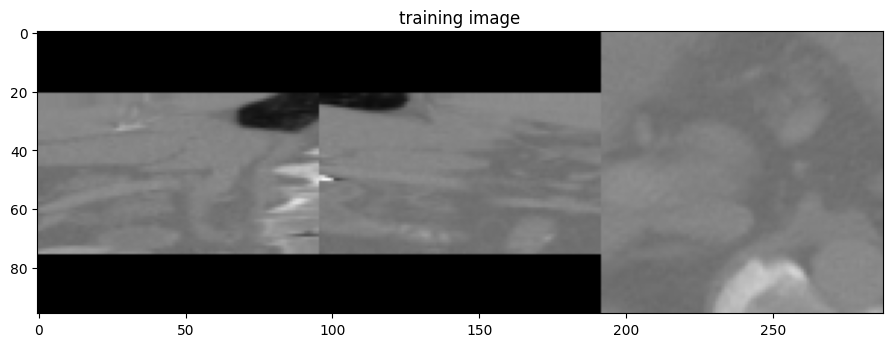

Val image shape torch.Size([1, 512, 512, 36])


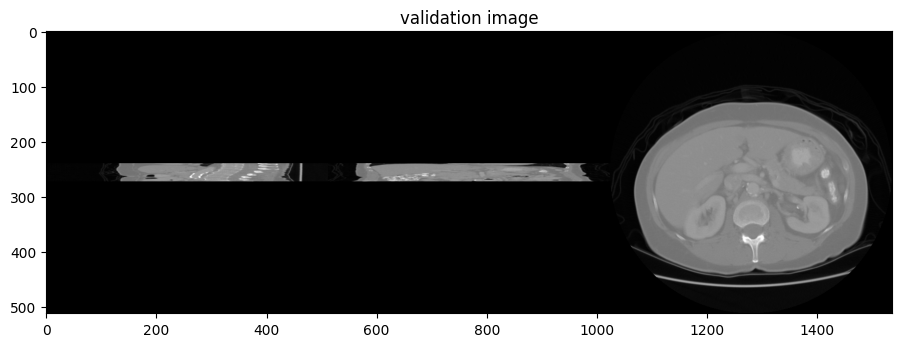

In [14]:
example_vis_img = dataset_train[0]["image"]
print(f"Train image shape {example_vis_img.shape}")
center_loc_axis = find_label_center_loc(example_vis_img.squeeze(0))
vis_image = get_xyz_plot(example_vis_img, center_loc_axis, mask_bool=False)
show_image(vis_image, title="training image")

example_vis_img = dataset_val[0]["image"]
print(f"Val image shape {example_vis_img.shape}")
center_loc_axis = find_label_center_loc(example_vis_img.squeeze(0))
vis_image = get_xyz_plot(example_vis_img, center_loc_axis, mask_bool=False)
show_image(vis_image, title="validation image")

## Initialize networks

In [15]:
device = torch.device("cuda")

args.autoencoder_def["num_splits"] = 1
autoencoder = define_instance(args, "autoencoder_def").to(device)
discriminator_norm = "INSTANCE"
discriminator = PatchDiscriminator(
    spatial_dims=args.spatial_dims,
    num_layers_d=3,
    channels=32,
    in_channels=1,
    out_channels=1,
    norm=discriminator_norm,
).to(device)

## Training config

In [16]:
# config loss and loss weight
if args.recon_loss == "l2":
    intensity_loss = MSELoss()
    print("Use l2 loss")
else:
    intensity_loss = L1Loss(reduction="mean")
    print("Use l1 loss")
adv_loss = PatchAdversarialLoss(criterion="least_squares")

loss_perceptual = (
    PerceptualLoss(spatial_dims=3, network_type="squeeze", is_fake_3d=True, fake_3d_ratio=0.2).eval().to(device)
)

# config optimizer and lr scheduler
optimizer_g = torch.optim.Adam(params=autoencoder.parameters(), lr=args.lr, eps=1e-06 if args.amp else 1e-08)
optimizer_d = torch.optim.Adam(params=discriminator.parameters(), lr=args.lr * 0.5, eps=1e-06 if args.amp else 1e-08)


# please adjust the learning rate warmup rule based on your dataset and n_epochs
def warmup_rule(epoch):
    # learning rate warmup rule
    if epoch < 10:
        return 0.01
    elif epoch < 20:
        return 0.1
    elif epoch < 40:
        return 0.3
    elif epoch < 60:
        return 0.6
    else:
        return 1.0



scheduler_g = lr_scheduler.LambdaLR(optimizer_g, lr_lambda=warmup_rule)
scheduler_d = lr_scheduler.LambdaLR(optimizer_d, lr_lambda=warmup_rule)

# set AMP scaler
if args.amp:
    # test use mean reduction for everything
    scaler_g = GradScaler("cuda", init_scale=2.0**8, growth_factor=1.5)
    scaler_d = GradScaler("cuda", init_scale=2.0**8, growth_factor=1.5)

Use l1 loss
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 185MB/s]


## If finetune, load pretrained model weights

In [18]:
# 断点续训优先级最高，覆盖 finetune 逻辑
state_path = os.path.join(args.model_dir, "training_state.pt")

if os.path.exists(state_path):
    # 有断点，从断点恢复
    state = torch.load(state_path)
    start_epoch = state["epoch"] + 1
    total_step = state["total_step"]
    best_val_recon_epoch_loss = state["best_val_loss"]
    autoencoder.load_state_dict(torch.load(trained_g_path))
    discriminator.load_state_dict(torch.load(trained_d_path))
    # 恢复 optimizer 状态，保留 Adam 动量
    optimizer_g.load_state_dict(state["optimizer_g"])
    optimizer_d.load_state_dict(state["optimizer_d"])
    # 恢复后覆盖 lr，让新参数生效
    for pg in optimizer_g.param_groups:
        pg['lr'] = args.lr
    for pg in optimizer_d.param_groups:
        pg['lr'] = args.lr * 0.5
    scheduler_g.load_state_dict(state["scheduler_g"])
    scheduler_d.load_state_dict(state["scheduler_d"])
    if args.amp:
        scaler_g.load_state_dict(state["scaler_g"])
        scaler_d.load_state_dict(state["scaler_d"])
    print(f"✅ 从断点恢复，继续从 Epoch {start_epoch} 开始")

elif args.finetune:
    checkpoint_autoencoder = torch.load(args.trained_autoencoder_path)
    if "unet_state_dict" in checkpoint_autoencoder.keys():
        checkpoint_autoencoder = checkpoint_autoencoder["unet_state_dict"]
    autoencoder.load_state_dict(checkpoint_autoencoder)
    print(f"Finetune on pretrained model {args.trained_autoencoder_path}")

else:
    print("Train from scratch!")

KeyError: 'optimizer_g'

In [ ]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
# 检查所有必需变量是否已定义
required_vars = [
    'autoencoder', 'discriminator',
    'optimizer_g', 'optimizer_d',
    'scheduler_g', 'scheduler_d',
    'scaler_g', 'scaler_d',
    'dataloader_train', 'dataloader_val',
    'args', 'device',
    'intensity_loss', 'KL_loss', 'loss_perceptual', 'adv_loss',
    'trained_g_path', 'trained_d_path',
    'dynamic_infer', 'find_label_center_loc', 'get_xyz_plot'
]

for var in required_vars:
    status = "✅" if var in dir() or var in vars() else "❌ 未定义"
    print(f"{status}  {var}")

## Training

In [ ]:
import os
import torch
import wandb
import gc
from tqdm.auto import tqdm
from google.colab import userdata

# ============================================================
# 1. W&B 登录与初始化（修复：先确保 args 已定义，再初始化）
# ============================================================
use_wandb = False  # 修复：用 flag 防止 init 失败后 log 静默出错

try:
    os.environ["WANDB_API_KEY"] = userdata.get('WANDB_API_KEY')
    wandb.login()

    run = wandb.init(
        project="MAISI_VAE_Training",
        name=f"L4_Patch64_BS{args.batch_size}",  # 确保 args 在此之前已定义
        config=vars(args)
    )
    config = wandb.config
    use_wandb = True
    print("✅ W&B 初始化成功")

except Exception as e:
    print(f"⚠️ W&B 初始化失败，将跳过所有日志记录。错误: {e}")
    # 不再静默吞掉异常，明确打印并继续训练

# ============================================================
# 2. 变量初始化
# ============================================================
val_interval = args.val_interval
best_val_recon_epoch_loss = float("inf")
total_step = 0
start_epoch = 0
max_epochs = args.n_epochs

# Setup validation inferer
val_inferer = (
    SlidingWindowInferer(
        roi_size=args.val_sliding_window_patch_size,
        sw_batch_size=1,
        progress=False,
        overlap=0.25,
        device=torch.device('cuda'),
        sw_device=torch.device('cuda'),
    )
    if args.val_sliding_window_patch_size
    else SimpleInferer()
)


def loss_weighted_sum(losses):
    return (
        losses["recons_loss"]
        + args.kl_weight * losses["kl_loss"]
        + args.perceptual_weight * losses["p_loss"]
    )


# ============================================================
# 3. 训练与验证循环
# ============================================================
for epoch in range(start_epoch, max_epochs):
    current_lr = scheduler_g.get_last_lr()[0]  # 修复：get_lr() 在某些版本已废弃
    print(f"\n🚀 Starting Epoch {epoch} | lr: {current_lr:.6f}")

    autoencoder.train()
    discriminator.train()
    train_epoch_losses = {"recons_loss": 0.0, "kl_loss": 0.0, "p_loss": 0.0}

    progress_bar = tqdm(dataloader_train, desc=f"Epoch {epoch} Train")

    for batch in progress_bar:
        images = batch["image"].to(device).contiguous()
        optimizer_g.zero_grad(set_to_none=True)
        optimizer_d.zero_grad(set_to_none=True)

        try:
            with autocast("cuda", enabled=args.amp):
                # --- Train Generator ---
                reconstruction, z_mu, z_sigma = autoencoder(images)
                losses = {
                    "recons_loss": intensity_loss(reconstruction, images),
                    "kl_loss": KL_loss(z_mu, z_sigma),
                    "p_loss": loss_perceptual(reconstruction.float(), images.float()),
                }
                logits_fake = discriminator(reconstruction.contiguous().float())[-1]
                generator_loss = adv_loss(logits_fake, target_is_real=True, for_discriminator=False)
                loss_g = loss_weighted_sum(losses) + args.adv_weight * generator_loss

                if args.amp:
                    scaler_g.scale(loss_g).backward()
                    scaler_g.step(optimizer_g)
                    scaler_g.update()
                else:
                    loss_g.backward()
                    optimizer_g.step()

                # --- Train Discriminator ---
                logits_fake_d = discriminator(reconstruction.contiguous().detach())[-1]
                loss_d_fake = adv_loss(logits_fake_d, target_is_real=False, for_discriminator=True)
                logits_real = discriminator(images.contiguous().detach())[-1]
                loss_d_real = adv_loss(logits_real, target_is_real=True, for_discriminator=True)
                loss_d = (loss_d_fake + loss_d_real) * 0.5

                if args.amp:
                    scaler_d.scale(loss_d).backward()
                    scaler_d.step(optimizer_d)
                    scaler_d.update()
                else:
                    loss_d.backward()
                    optimizer_d.step()

            # --- 记录每步指标（修复：用 step= 参数，不混入字段）---
            total_step += 1
            step_log = {
                "train/recons_loss_iter": losses["recons_loss"].item(),
                "train/kl_loss_iter": losses["kl_loss"].item(),
                "train/p_loss_iter": losses["p_loss"].item(),
                "train/gen_adv_loss_iter": generator_loss.item(),
                "train/disc_loss_iter": loss_d.item(),
                "train/lr": current_lr,
            }
            if use_wandb:
                wandb.log(step_log, step=total_step)  # 修复：显式传 step

            # --- 训练中每 100 步抽样上传重构图（新增）---
            if use_wandb and total_step % 100 == 0:
                with torch.no_grad():
                    center_loc = find_label_center_loc(images[0, 0, ...])
                    vis_train_orig = get_xyz_plot(images[0, ...], center_loc, mask_bool=False)
                    vis_train_recon = get_xyz_plot(reconstruction[0, ...], center_loc, mask_bool=False)
                    wandb.log(
                        {
                            "train/recon_sample": [
                                wandb.Image(vis_train_orig, caption="Orig"),
                                wandb.Image(vis_train_recon, caption=f"Recon Step {total_step}"),
                            ]
                        },
                        step=total_step,
                    )

            for loss_name, loss_value in losses.items():
                train_epoch_losses[loss_name] += loss_value.item()

            progress_bar.set_postfix(
                {"recon": f"{losses['recons_loss'].item():.4f}", "d_loss": f"{loss_d.item():.4f}"}
            )

        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"\n⚠️ OOM detected at step {total_step}. Clearing cache...")
                for p in autoencoder.parameters():
                    if p.grad is not None:
                        del p.grad
                for p in discriminator.parameters():
                    if p.grad is not None:
                        del p.grad
                torch.cuda.empty_cache()
                gc.collect()
                continue
            else:
                raise e

    # -------------------------------------------------------
    # Epoch 结束：更新 LR、记录 Epoch 级指标、保存模型
    # -------------------------------------------------------
    scheduler_g.step()
    scheduler_d.step()

    num_train_batches = len(dataloader_train)
    epoch_log = {
        f"train/{k}_epoch": v / num_train_batches
        for k, v in train_epoch_losses.items()
    }
    epoch_log["epoch"] = epoch

    if use_wandb:
        wandb.log(epoch_log, step=total_step)  # 修复：显式传 step，与 iter 级对齐

    torch.save(autoencoder.state_dict(), trained_g_path)
    torch.save(discriminator.state_dict(), trained_d_path)

    # 同时保存训练状态
    torch.save({
        "epoch": epoch,
        "total_step": total_step,
        "best_val_loss": best_val_recon_epoch_loss,
    }, os.path.join(args.model_dir, "training_state.pt"))

    print(f"💾 Checkpoint saved at epoch {epoch}")

    # -------------------------------------------------------
    # 4. Validation
    # -------------------------------------------------------
    if epoch % val_interval == 0:
        autoencoder.eval()
        val_epoch_losses = {"recons_loss": 0.0, "kl_loss": 0.0, "p_loss": 0.0}
        last_z_mu = None  # 用于计算 scale factor

        for batch in tqdm(dataloader_val, desc=f"Epoch {epoch} Val"):
            with torch.no_grad():
                with autocast("cuda", enabled=args.amp):
                    images = batch["image"]
                    reconstruction, z_mu, z_sigma = dynamic_infer(val_inferer, autoencoder, images)
                    reconstruction = reconstruction.to(device)
                    val_epoch_losses["recons_loss"] += intensity_loss(
                        reconstruction, images.to(device)
                    ).item()
                    val_epoch_losses["kl_loss"] += KL_loss(z_mu, z_sigma).item()
                    val_epoch_losses["p_loss"] += loss_perceptual(
                        reconstruction, images.to(device)
                    ).item()
                    last_z_mu = z_mu  # 保存最后一个 batch 用于 scale factor

        num_val_batches = len(dataloader_val)
        for key in val_epoch_losses:
            val_epoch_losses[key] /= num_val_batches

        val_loss_g = loss_weighted_sum(val_epoch_losses)

        # 监控隐空间尺度因子
        scale_factor_sample = 1.0 / (last_z_mu.flatten().std().item() + 1e-6)

        if use_wandb:
            val_log = {f"val/{k}": v for k, v in val_epoch_losses.items()}
            val_log["val/total_vae_loss"] = val_loss_g
            val_log["val/scale_factor"] = scale_factor_sample
            wandb.log(val_log, step=total_step)  # 修复：显式传 step

            # --- 5. 可视化重构结果（修复：step 对齐）---
            center_loc_axis = find_label_center_loc(images[0, 0, ...])
            vis_image = get_xyz_plot(images[0, ...], center_loc_axis, mask_bool=False)
            vis_recon_image = get_xyz_plot(reconstruction[0, ...], center_loc_axis, mask_bool=False)

            wandb.log(
                {
                    "val/orig_vs_recon": [
                        wandb.Image(vis_image, caption="Original"),
                        wandb.Image(vis_recon_image, caption=f"Recon Epoch {epoch}"),
                    ]
                },
                step=total_step,
            )

        print(
            f"📊 Val Loss: {val_loss_g:.6f} | "
            f"recon={val_epoch_losses['recons_loss']:.4f} | "
            f"kl={val_epoch_losses['kl_loss']:.4f} | "
            f"scale_factor={scale_factor_sample:.4f}"
        )

        if val_loss_g < best_val_recon_epoch_loss:
            best_val_recon_epoch_loss = val_loss_g
            best_path = f"{trained_g_path[:-3]}_best.pt"
            torch.save(autoencoder.state_dict(), best_path)
            print(f"✨ New best val loss: {val_loss_g:.6f} → saved to {best_path}")

# ============================================================
# 训练结束
# ============================================================
if use_wandb:
    wandb.finish()
